In [ ]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [ ]:
df=pd.read_csv("Diabetes_MIHIR.csv" )

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

In [ ]:
print(df.shape)
df.head()


(97297, 31)


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [ ]:
df.describe()

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [ ]:
df.isnull().sum()

,0
Age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


In [ ]:
df['diagnosed_diabetes'].isnull()

,diagnosed_diabetes
0,False
1,False
2,False
3,False
4,False
...,...
97292,False
97293,False
97294,False
97295,False


In [ ]:
df[df['diagnosed_diabetes'].isnull()]

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes


In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

In [ ]:
numerical=[feature for feature in df.columns if df[feature].dtype != "O"]


In [ ]:
categorical=[feature for feature in df.columns if df[feature].dtype == "O"]

In [ ]:
categorical

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'diabetes_stage']

In [ ]:
numerical

['Age',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diagnosed_diabetes']

In [ ]:
df.drop(columns=['income_level'],inplace=True)

In [ ]:
df['diagnosed_diabetes'].value_counts()

,count
diagnosed_diabetes,
1,58382
0,38915


In [ ]:
df.drop(columns=['diabetes_stage'],inplace=True)

In [ ]:
df.drop(columns=['diabetes_risk_score'],inplace=True)

<Axes: xlabel='Age', ylabel='Density'>

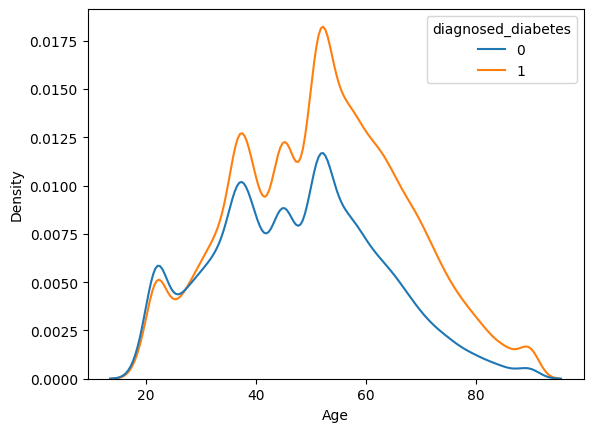

In [ ]:
sns.kdeplot(x='Age',data=df,hue='diagnosed_diabetes')

In [ ]:
df[['Age','diagnosed_diabetes']].corr()

,Age,diagnosed_diabetes
Age,1.000000,0.138098
diagnosed_diabetes,0.138098,1.000000


In [ ]:
age_55_60 = df[(df['Age'] >= 55) & (df['Age'] <= 60)]
diabetes_counts = age_55_60['diagnosed_diabetes'].value_counts().rename(index={1: 'Diabetic', 0: 'Non-Diabetic'})
display(diabetes_counts)

,count
diagnosed_diabetes,
Diabetic,8084
Non-Diabetic,4802


In [ ]:
numerical

['Age',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diagnosed_diabetes']

In [ ]:
categorical

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'diabetes_stage']

In [ ]:
df['diagnosed_diabetes'].value_counts()

,count
diagnosed_diabetes,
1,58382
0,38915


<Axes: xlabel='gender', ylabel='count'>

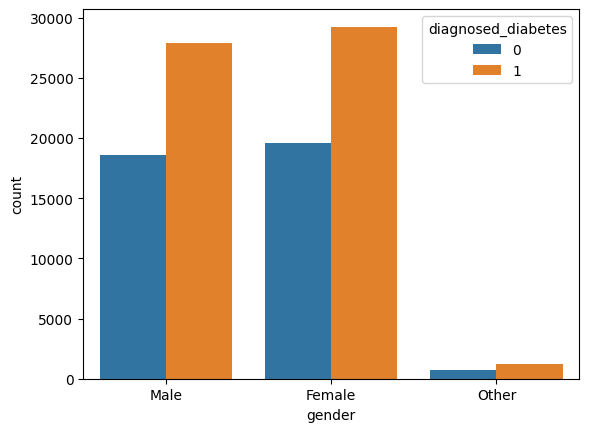

In [ ]:
sns.countplot(x='gender',data=df,hue='diagnosed_diabetes')

In [ ]:
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
df[df['gender']=='Other']['diagnosed_diabetes'].value_counts()

,count
diagnosed_diabetes,
1,1226
0,738


In [ ]:
df=df[df["gender"]!='Other']

In [ ]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['gender']=df['gender'].map({'Male':1,'Female':0})

In [ ]:
df['gender']

,gender
0,1
1,0
2,1
3,0
4,1
...,...
97292,1
97293,0
97294,0
97295,0


In [ ]:
df['gender']=df['gender'].astype(int)

In [ ]:
numerical=[feature for feature in df.columns if df[feature].dtype != "O"]


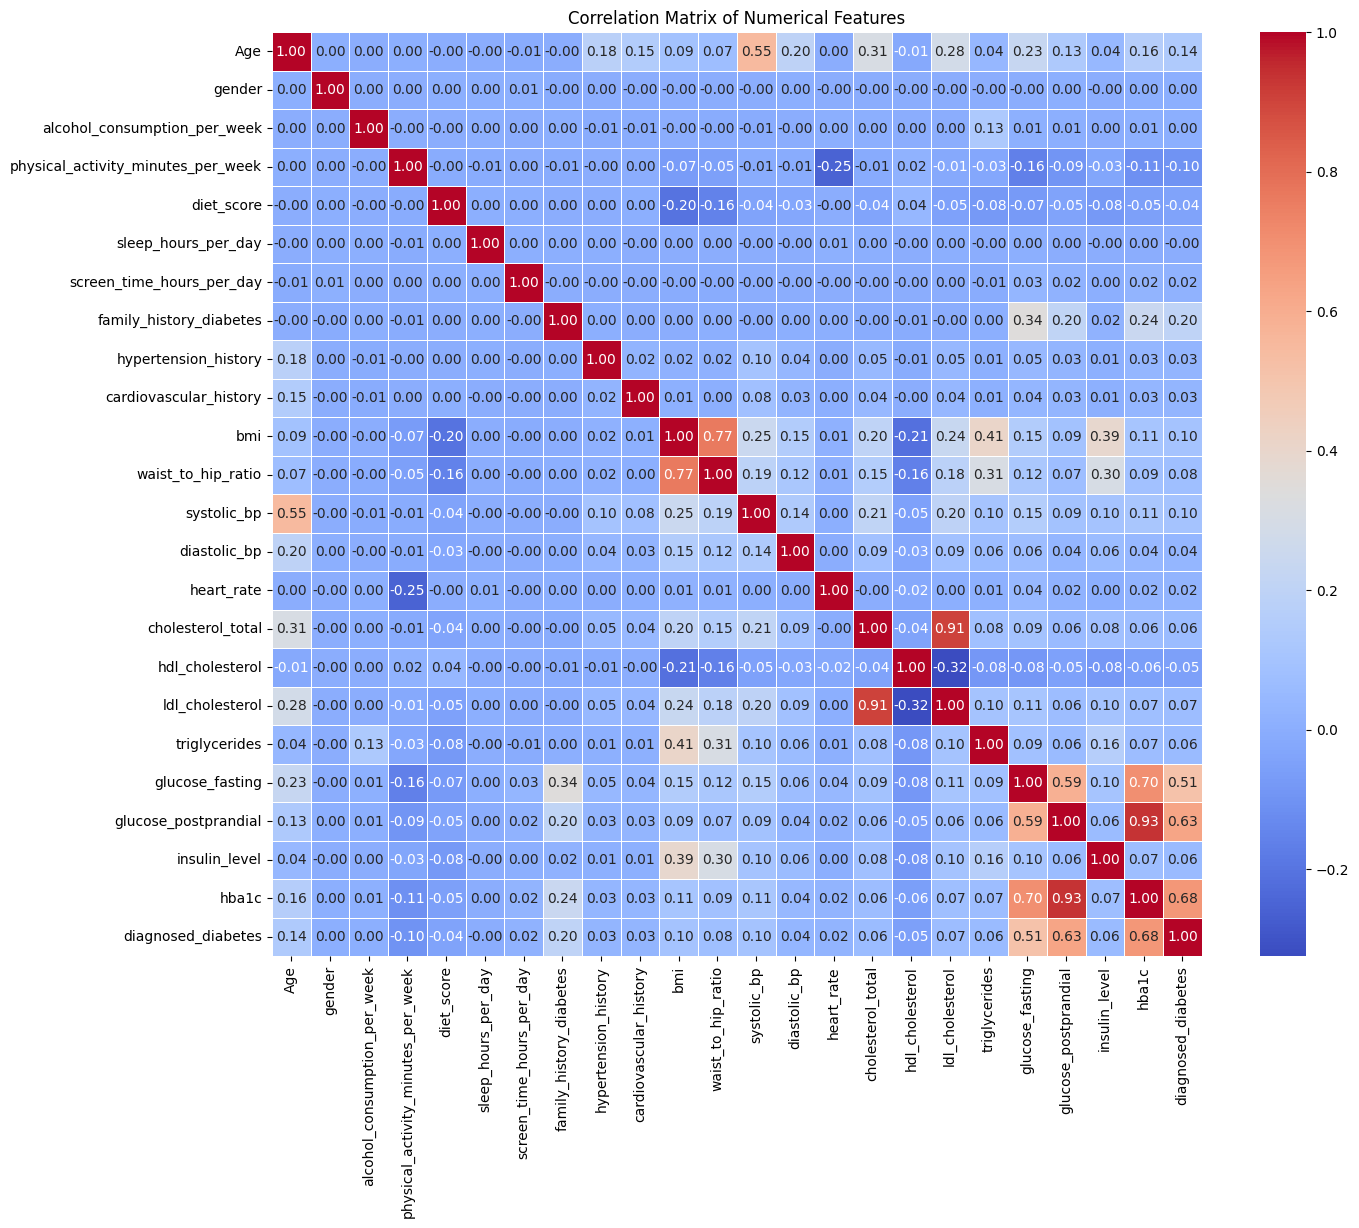

In [ ]:
plt.figure(figsize=(15, 12)) # Adjust figure size for better readability
sns.heatmap(df[numerical].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
numerical

['Age',
 'gender',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diagnosed_diabetes']

<Axes: xlabel='glucose_postprandial', ylabel='Density'>

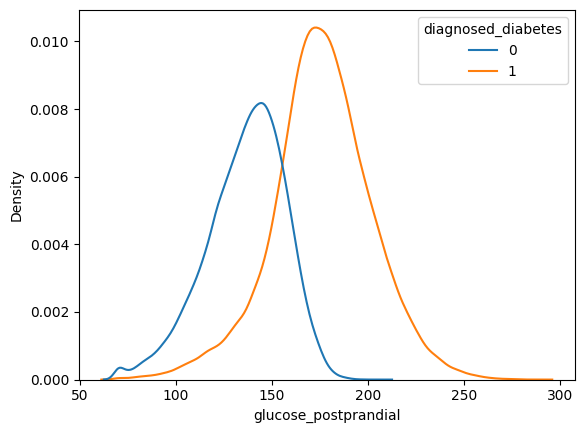

In [ ]:
sns.kdeplot(x='glucose_postprandial',data=df,hue='diagnosed_diabetes')

<Axes: xlabel='hba1c', ylabel='Density'>

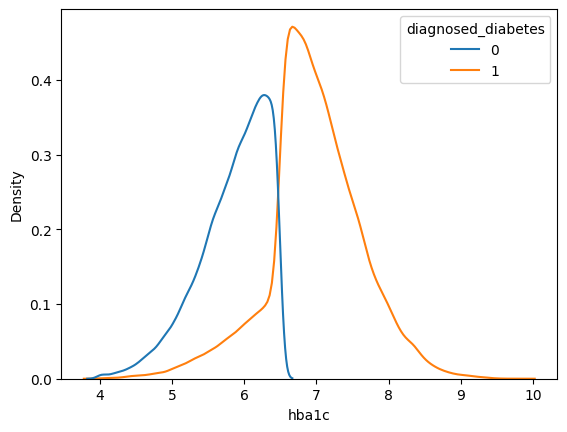

In [ ]:
sns.kdeplot(x='hba1c',data=df,hue='diagnosed_diabetes')

<Axes: xlabel='insulin_level', ylabel='Density'>

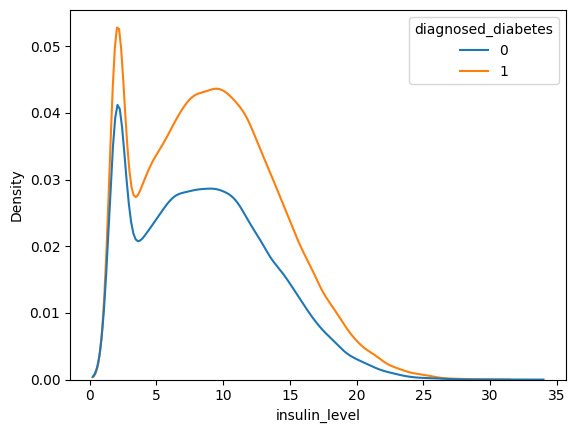

In [ ]:
sns.kdeplot(x='insulin_level',data=df,hue='diagnosed_diabetes')

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']
X_num = X.select_dtypes(include=['int64', 'float64'])
mi_scores = mutual_info_classif(X_num, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_num.columns,
    'MI Score': mi_scores
})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)


print(mi_df)

                               Feature  MI Score
22                               hba1c  0.441148
20                glucose_postprandial  0.286715
19                     glucose_fasting  0.164268
7              family_history_diabetes  0.024111
0                                  Age  0.009995
1                               gender  0.007500
3   physical_activity_minutes_per_week  0.004856
12                         systolic_bp  0.004529
11                  waist_to_hip_ratio  0.004246
2         alcohol_consumption_per_week  0.003693
15                   cholesterol_total  0.003287
16                     hdl_cholesterol  0.002871
10                                 bmi  0.002826
14                          heart_rate  0.002757
8                 hypertension_history  0.001936
4                           diet_score  0.001529
21                       insulin_level  0.001498
9               cardiovascular_history  0.000876
17                     ldl_cholesterol  0.000706
18                  

<Axes: xlabel='hypertension_history', ylabel='Density'>

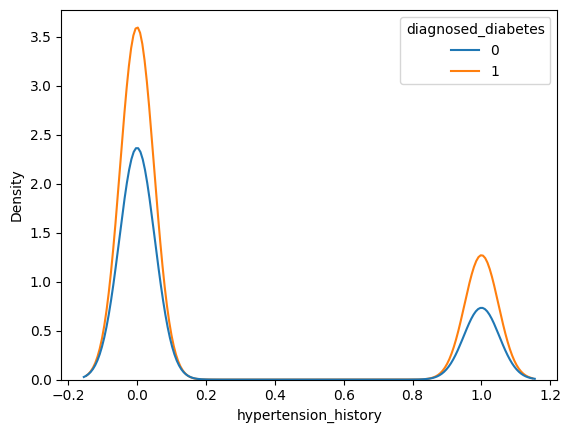

In [ ]:
sns.kdeplot(x='hypertension_history',data=df,hue='diagnosed_diabetes')

<Axes: xlabel='diet_score', ylabel='Density'>

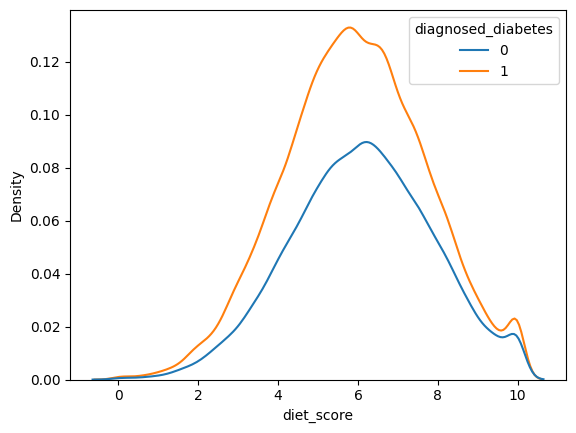

In [ ]:
sns.kdeplot(x='diet_score',data=df,hue='diagnosed_diabetes')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95333 entries, 0 to 97296
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 95333 non-null  int64  
 1   gender                              95333 non-null  int64  
 2   ethnicity                           95333 non-null  object 
 3   education_level                     95333 non-null  object 
 4   employment_status                   95333 non-null  object 
 5   smoking_status                      95333 non-null  object 
 6   alcohol_consumption_per_week        95333 non-null  int64  
 7   physical_activity_minutes_per_week  95333 non-null  int64  
 8   diet_score                          95333 non-null  float64
 9   sleep_hours_per_day                 95333 non-null  float64
 10  screen_time_hours_per_day           95333 non-null  float64
 11  family_history_diabetes             95333 non-

<Axes: xlabel='hdl_cholesterol', ylabel='Density'>

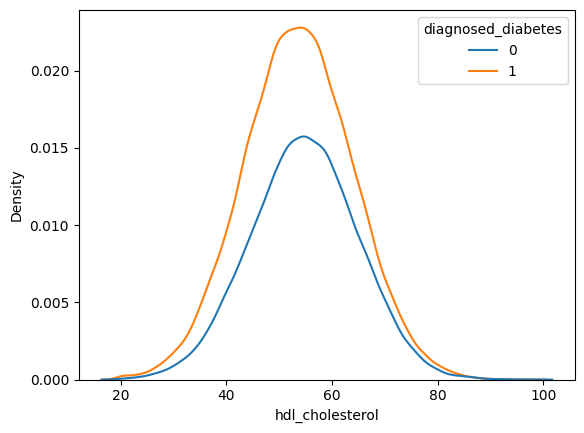

In [ ]:
sns.kdeplot(x='hdl_cholesterol', data=df, hue="diagnosed_diabetes")

<Axes: xlabel='ldl_cholesterol', ylabel='Density'>

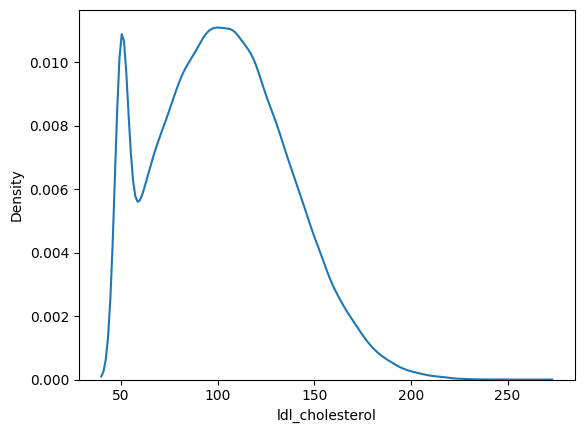

In [ ]:
sns.kdeplot(x='ldl_cholesterol',data=df)

<Axes: xlabel='heart_rate', ylabel='Density'>

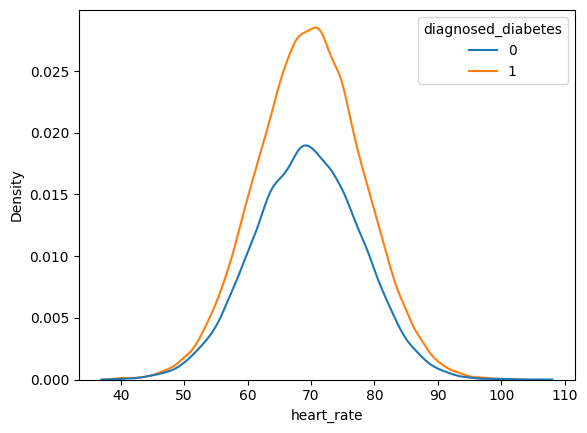

In [ ]:
sns.kdeplot(x='heart_rate',data=df,hue="diagnosed_diabetes")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95333 entries, 0 to 97296
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 95333 non-null  int64  
 1   gender                              95333 non-null  int64  
 2   ethnicity                           95333 non-null  object 
 3   education_level                     95333 non-null  object 
 4   employment_status                   95333 non-null  object 
 5   smoking_status                      95333 non-null  object 
 6   alcohol_consumption_per_week        95333 non-null  int64  
 7   physical_activity_minutes_per_week  95333 non-null  int64  
 8   diet_score                          95333 non-null  float64
 9   sleep_hours_per_day                 95333 non-null  float64
 10  screen_time_hours_per_day           95333 non-null  float64
 11  family_history_diabetes             95333 non-

In [ ]:
df.drop(columns=['hdl_cholesterol'],inplace=True)

In [ ]:
df.drop(columns=['heart_rate','insulin_level'],inplace=True)

In [ ]:
df.drop(columns=['hypertension_history','cardiovascular_history','ldl_cholesterol','triglycerides'],inplace=True)

In [ ]:
df.drop(columns=['sleep_hours_per_day','screen_time_hours_per_day','diastolic_bp'],inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95333 entries, 0 to 97296
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 95333 non-null  int64  
 1   gender                              95333 non-null  int64  
 2   ethnicity                           95333 non-null  object 
 3   education_level                     95333 non-null  object 
 4   employment_status                   95333 non-null  object 
 5   smoking_status                      95333 non-null  object 
 6   alcohol_consumption_per_week        95333 non-null  int64  
 7   physical_activity_minutes_per_week  95333 non-null  int64  
 8   diet_score                          95333 non-null  float64
 9   family_history_diabetes             95333 non-null  int64  
 10  bmi                                 95333 non-null  float64
 11  waist_to_hip_ratio                  95333 non-

In [ ]:
categorical

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'diabetes_stage']

In [ ]:
numerical=[feature for feature in df.columns if df[feature].dtype != "O"]
categorical=[feature for feature in df.columns if df[feature].dtype == "O"]

In [ ]:
numerical

['Age',
 'gender',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'family_history_diabetes',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'cholesterol_total',
 'glucose_fasting',
 'glucose_postprandial',
 'hba1c',
 'diagnosed_diabetes']

In [ ]:
categorical

['ethnicity', 'education_level', 'employment_status', 'smoking_status']

In [ ]:
df['employment_status'].value_counts()

,count
employment_status,
Employed,57384
Retired,20734
Unemployed,11368
Student,5847


In [ ]:
df['education_level'].value_counts()

,count
education_level,
Highschool,42774
Graduate,33393
Postgraduate,14272
No formal,4894


<Axes: xlabel='employment_status', ylabel='diagnosed_diabetes'>

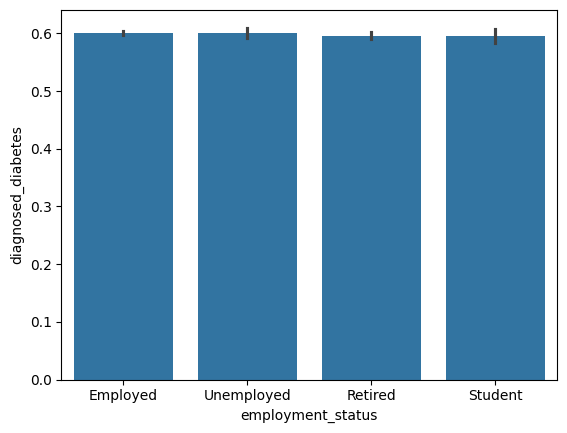

In [ ]:
sns.barplot(x='employment_status',data=df,y='diagnosed_diabetes')

<Axes: xlabel='employment_status', ylabel='count'>

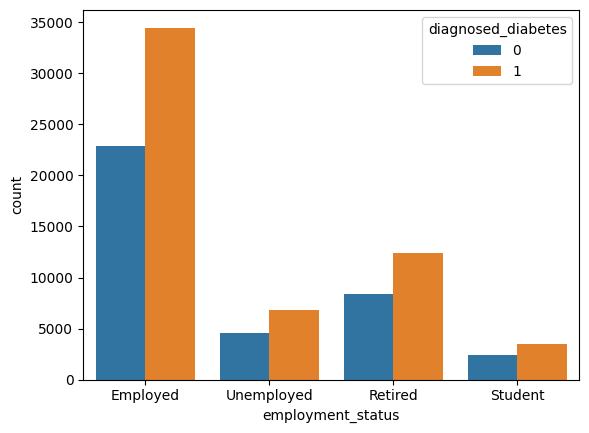

In [ ]:
sns.countplot(x='employment_status',data=df,hue="diagnosed_diabetes")

<Axes: xlabel='education_level', ylabel='diagnosed_diabetes'>

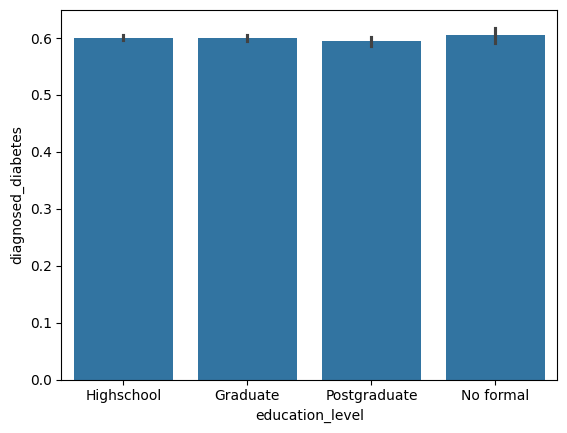

In [ ]:
sns.barplot(x='education_level',data=df,y="diagnosed_diabetes")

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(cat_cols)


Index(['ethnicity', 'education_level', 'employment_status', 'smoking_status'], dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le


In [ ]:
X = df_encoded.drop('diagnosed_diabetes', axis=1)
y = df_encoded['diagnosed_diabetes']


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)


In [ ]:
import pandas as pd

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)


                               Feature  MI Score
16                               hba1c  0.443306
15                glucose_postprandial  0.287422
14                     glucose_fasting  0.164728
9              family_history_diabetes  0.021722
0                                  Age  0.009371
1                               gender  0.008948
5                       smoking_status  0.006506
2                            ethnicity  0.006449
11                  waist_to_hip_ratio  0.004806
10                                 bmi  0.004446
12                         systolic_bp  0.004105
8                           diet_score  0.004030
3                      education_level  0.002930
7   physical_activity_minutes_per_week  0.002646
6         alcohol_consumption_per_week  0.002366
4                    employment_status  0.000436
13                   cholesterol_total  0.000000


In [ ]:
df.drop(columns=['employment_status','education_level'],inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95333 entries, 0 to 97296
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 95333 non-null  int64  
 1   gender                              95333 non-null  int64  
 2   ethnicity                           95333 non-null  object 
 3   smoking_status                      95333 non-null  object 
 4   alcohol_consumption_per_week        95333 non-null  int64  
 5   physical_activity_minutes_per_week  95333 non-null  int64  
 6   diet_score                          95333 non-null  float64
 7   family_history_diabetes             95333 non-null  int64  
 8   bmi                                 95333 non-null  float64
 9   waist_to_hip_ratio                  95333 non-null  float64
 10  systolic_bp                         95333 non-null  int64  
 11  cholesterol_total                   95333 non-

In [ ]:
X = df.drop(columns=['diagnosed_diabetes'])
y = df['diagnosed_diabetes']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Update numerical and categorical lists based on the current X_train columns
numerical = X_train.select_dtypes(include=np.number).columns.tolist()
categorical = X_train.select_dtypes(include='object').columns.tolist()

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first', handle_unknown='ignore') # Added handle_unknown for robustness
preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, categorical),
          ("StandardScaler", numeric_transformer, numerical)
    ]
)
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))

    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))



    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))


    print('='*35)
    print('\n')

Logistic Regression
Model performance for Training set
- Accuracy: 0.8592
- F1 score: 0.8587
- Precision: 0.8738
- Recall: 0.8943
- Roc Auc Score: 0.8505
----------------------------------
Model performance for Test set
- Accuracy: 0.8570
- F1 score: 0.8565
- Precision: 0.8711
- Recall: 0.8938
- Roc Auc Score: 0.8479


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9197
- F1 score: 0.9205
- Precision: 0.9998
- Recall: 0.8662
- Roc Auc Score: 0.9330




/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:52:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
Model performance for Training set
- Accuracy: 0.9455
- F1 score: 0.9460
- Precision: 0.9998
- Recall: 0.9093
- Roc Auc Score: 0.9545
----------------------------------
Model performance for Test set
- Accuracy: 0.9173
- F1 score: 0.9181
- Precision: 0.9910
- Recall: 0.8699
- Roc Auc Score: 0.9291


KNN
Model performance for Training set
- Accuracy: 0.8877
- F1 score: 0.8883
- Precision: 0.9257
- Recall: 0.8836
- Roc Auc Score: 0.8887
----------------------------------
Model performance for Test set
- Accuracy: 0.8362
- F1 score: 0.8369
- Precision: 0.8790
- Recall: 0.8428
- Roc Auc Score: 0.8346




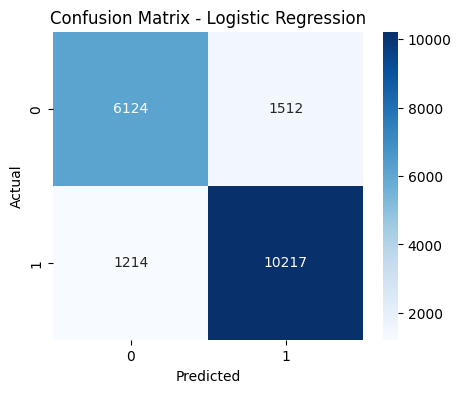

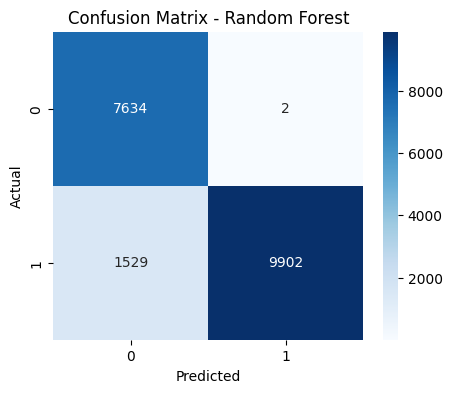

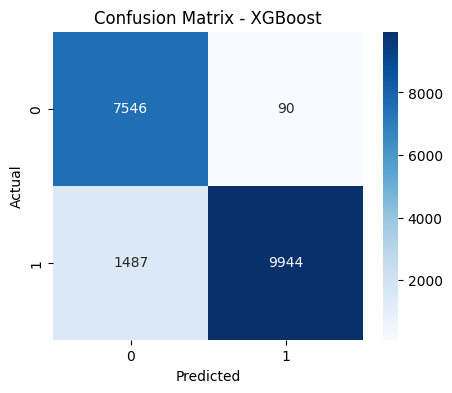

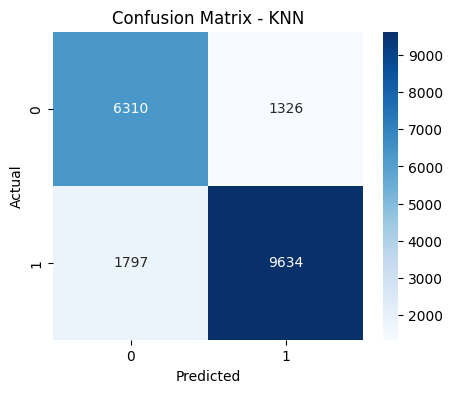

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models_list = list(models.values())
model_names = list(models.keys())

for name, model in zip(model_names, models_list):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


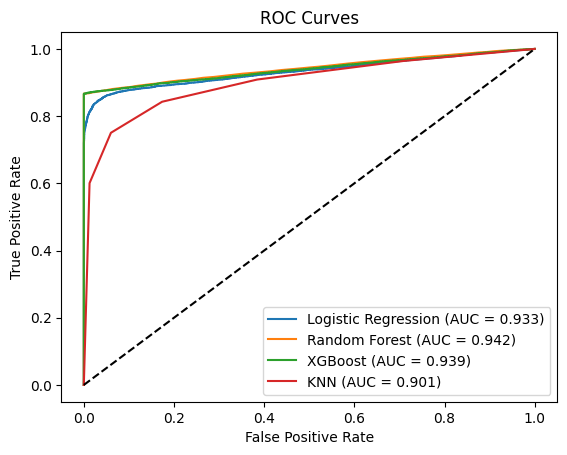

In [ ]:
from sklearn.metrics import roc_curve, auc

for name, model in zip(model_names, models_list):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


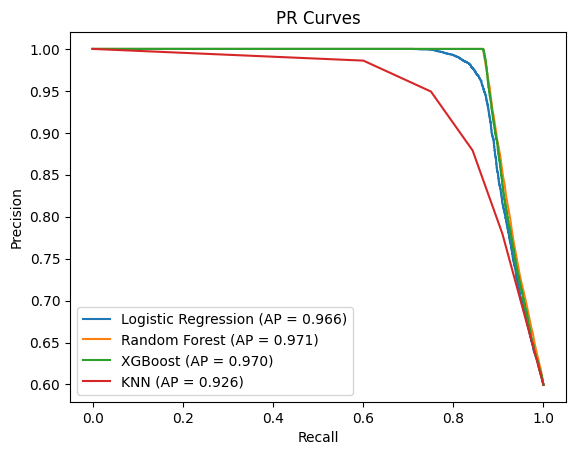

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

for name, model in zip(model_names, models_list):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curves")
plt.legend()
plt.show()


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000, random_state=42)

param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 5, 10, 50],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],  # these support L1
    'class_weight': [None, 'balanced']
}

lr_search = RandomizedSearchCV(
    log_reg,
    param_distributions=param_dist_lr,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print("Best Logistic Regression Params:", lr_search.best_params_)
print("Best Score:", lr_search.best_score_)


Best Logistic Regression Params: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.01}
Best Score: 0.9341137963158387


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

param_dist_xgb = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 1, 3, 5, 10],
    'min_child_weight': [1, 3, 5, 7]
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_search.best_params_)
print("Best XGB Score:", xgb_search.best_score_)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:08:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Params: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 10, 'colsample_bytree': 0.8}
Best XGB Score: 0.9468802824427152
